In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size = "5" color = 'red' ><b> ch01 DeepLearning </b></font>

# 1. 기존의 프로그램 방식
- 회귀분석(linear regression) 설명 사이트 : https://gbhat.com/machine_learning/linear_regression.html
- 오차함수 : MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE의 단점이 어느정도 해소. 이상치에 덜 민감), MAE(mean absolute erro error ; 절대값평균)
- https://jysden.medium.com/%EC%96%B8%EC%A0%9C-mse-mae-rmse%EB%A5%BC-%EC%82%AC%EC%9A%A9%ED%95%98%EB%8A%94%EA%B0%80-c473bd831c62
![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*XRXgMqrr5rq-V1rW7SkrtA.png)
- 경사하강법 설명
-https://www.mql5.com/ko/articles/11200

In [11]:
# 섭씨 온도를 입력 받아 화씨 온도를 출력하는 프로그램
def celsius_to_faherenheit(c) :
    return c * 1.8 + 32

In [5]:
input_c = int(input('섭씨온도? : '))
print('화씨온도 :',celsius_to_faherenheit(input_c))

섭씨온도? : 2
화씨온도 : 35.6


# 2. 머신러닝 프로그램 방식
```
1. 데이터 확보 및 생성 
2. 데이터 전처리 : 
    스케일 조정
    훈련데이터(학습데이터셋) + 검증용데이터셋 + 테스트데이터셋 분할
3. 모델 구성
4. 모델 학습 과정 설정
5. 모델 학습
6. 모델 평가(시험 데이터 셋(테스트 데이터 셋) 활용)
    <모델 저장>
7. 모델 사용(입력 값이 주어지면 예측 값 받기)
```

## 2.1 노이즈가 없는 데이터로 실습

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# 1. 데이터 생성(확보 및 생성)
data_C = np.arange(100) # 0 부터 99 까지
data_C # 독립변수(입력변수)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [13]:
data_F = celsius_to_faherenheit(data_C)
data_F # 종속변수(타겟변수, 출력변수)

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [14]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해 스케일 조정
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('학습 시 쓸 독립변수 :',scaled_data_C)
print('')
print('학습 시 쓸 타겟변수 :',scaled_data_F)

학습 시 쓸 독립변수 : [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]

학습 시 쓸 타겟변수 : [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  

In [15]:
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [16]:
# 3. 모델 구성
from tensorflow.keras.models import Sequential # 모델 생성용 클래스
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 Layer 층 지정

model = Sequential()
# model.add( Input( shape=(1,) ) ) # 입력값
# model.add(Dense(1)) # 출력층
model.add(Dense(units = 1, # 타겟(종속) 변수의 갯수 => 분류 분석 : 덥다, 안덥다 = 2개 경우
                input_shape=(1,)# 입력(독립) 변수의 shape
                )) 

In [17]:
# 4. 모델 학습과정 설정
model.compile(loss='mse', # 손실 함수 : 오차의 제곱을 통해 loss 구하겠다 - 모델 학습 중 오차를 최소화 하기 위해 사용
             optimizer = "rmsprop", #옵티마이저 : 경사 선택 보폭
             metrics=['mae'], # 평가지표
             )
# mse 오차 제곱의 평균
# mae 오차 절대값의 평균(이상치 영향이 감소)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [10]:
# 학습 전 예측
model.predict(np.array([[0],
                      [0.01]])) # 섭씨온도 0, 1도는 화씨온도 몇도?

1/1 [==============================] - 0s 136ms/step


array([[0.        ],
       [0.01430813]], dtype=float32)

In [22]:
# 학습전 모델 저장
model.save('model/before_learning.h5')

In [ ]:
# 5. 모델 학습 - 1번만 실행
hist = model.fit(scaled_data_C, # 입력 변수(훈련데이터)
                 scaled_data_F, # 타겟 변수(훈련데이터)
                epochs = 10000000, # 학습 회수
                verbose = 2 # 학습 시 출력 여부(0: 출력X, 1 : 간단한 출력, 2 : 깊은 출력)
                )

Epoch 1/10000000
4/4 - 2s - loss: 3.2550 - mae: 1.6328 - 2s/epoch - 412ms/step
Epoch 2/10000000
4/4 - 0s - loss: 3.2142 - mae: 1.6213 - 6ms/epoch - 2ms/step
Epoch 3/10000000
4/4 - 0s - loss: 3.1882 - mae: 1.6141 - 22ms/epoch - 5ms/step
Epoch 4/10000000
4/4 - 0s - loss: 3.1628 - mae: 1.6067 - 8ms/epoch - 2ms/step
Epoch 5/10000000
4/4 - 0s - loss: 3.1388 - mae: 1.5998 - 22ms/epoch - 5ms/step
Epoch 6/10000000
4/4 - 0s - loss: 3.1178 - mae: 1.5939 - 7ms/epoch - 2ms/step
Epoch 7/10000000
4/4 - 0s - loss: 3.0947 - mae: 1.5873 - 12ms/epoch - 3ms/step
Epoch 8/10000000
4/4 - 0s - loss: 3.0737 - mae: 1.5811 - 6ms/epoch - 2ms/step
Epoch 9/10000000
4/4 - 0s - loss: 3.0536 - mae: 1.5753 - 11ms/epoch - 3ms/step
Epoch 10/10000000
4/4 - 0s - loss: 3.0342 - mae: 1.5697 - 9ms/epoch - 2ms/step
Epoch 11/10000000
4/4 - 0s - loss: 3.0139 - mae: 1.5638 - 8ms/epoch - 2ms/step
Epoch 12/10000000
4/4 - 0s - loss: 2.9926 - mae: 1.5576 - 9ms/epoch - 2ms/step
Epoch 13/10000000
4/4 - 0s - loss: 2.9707 - mae: 1.5511 

Epoch 105/10000000
4/4 - 0s - loss: 1.4608 - mae: 1.0239 - 10ms/epoch - 2ms/step
Epoch 106/10000000
4/4 - 0s - loss: 1.4478 - mae: 1.0186 - 4ms/epoch - 928us/step
Epoch 107/10000000
4/4 - 0s - loss: 1.4341 - mae: 1.0129 - 7ms/epoch - 2ms/step
Epoch 108/10000000
4/4 - 0s - loss: 1.4208 - mae: 1.0074 - 5ms/epoch - 1ms/step
Epoch 109/10000000
4/4 - 0s - loss: 1.4075 - mae: 1.0019 - 9ms/epoch - 2ms/step
Epoch 110/10000000
4/4 - 0s - loss: 1.3948 - mae: 0.9968 - 5ms/epoch - 1ms/step
Epoch 111/10000000
4/4 - 0s - loss: 1.3828 - mae: 0.9917 - 9ms/epoch - 2ms/step
Epoch 112/10000000
4/4 - 0s - loss: 1.3717 - mae: 0.9870 - 7ms/epoch - 2ms/step
Epoch 113/10000000
4/4 - 0s - loss: 1.3587 - mae: 0.9818 - 6ms/epoch - 1ms/step
Epoch 114/10000000
4/4 - 0s - loss: 1.3445 - mae: 0.9757 - 7ms/epoch - 2ms/step
Epoch 115/10000000
4/4 - 0s - loss: 1.3318 - mae: 0.9705 - 6ms/epoch - 1ms/step
Epoch 116/10000000
4/4 - 0s - loss: 1.3185 - mae: 0.9649 - 6ms/epoch - 2ms/step
Epoch 117/10000000
4/4 - 0s - loss: 1

Epoch 208/10000000
4/4 - 0s - loss: 0.4733 - mae: 0.5644 - 9ms/epoch - 2ms/step
Epoch 209/10000000
4/4 - 0s - loss: 0.4679 - mae: 0.5616 - 7ms/epoch - 2ms/step
Epoch 210/10000000
4/4 - 0s - loss: 0.4616 - mae: 0.5579 - 9ms/epoch - 2ms/step
Epoch 211/10000000
4/4 - 0s - loss: 0.4559 - mae: 0.5547 - 7ms/epoch - 2ms/step
Epoch 212/10000000
4/4 - 0s - loss: 0.4502 - mae: 0.5514 - 10ms/epoch - 3ms/step
Epoch 213/10000000
4/4 - 0s - loss: 0.4445 - mae: 0.5484 - 5ms/epoch - 1ms/step
Epoch 214/10000000
4/4 - 0s - loss: 0.4394 - mae: 0.5453 - 8ms/epoch - 2ms/step
Epoch 215/10000000
4/4 - 0s - loss: 0.4330 - mae: 0.5416 - 10ms/epoch - 2ms/step
Epoch 216/10000000
4/4 - 0s - loss: 0.4274 - mae: 0.5385 - 6ms/epoch - 1ms/step
Epoch 217/10000000
4/4 - 0s - loss: 0.4214 - mae: 0.5352 - 6ms/epoch - 2ms/step
Epoch 218/10000000
4/4 - 0s - loss: 0.4155 - mae: 0.5317 - 11ms/epoch - 3ms/step
Epoch 219/10000000
4/4 - 0s - loss: 0.4111 - mae: 0.5291 - 4ms/epoch - 1ms/step
Epoch 220/10000000
4/4 - 0s - loss: 0

Epoch 311/10000000
4/4 - 0s - loss: 0.1841 - mae: 0.3715 - 8ms/epoch - 2ms/step
Epoch 312/10000000
4/4 - 0s - loss: 0.1835 - mae: 0.3709 - 10ms/epoch - 2ms/step
Epoch 313/10000000
4/4 - 0s - loss: 0.1829 - mae: 0.3704 - 6ms/epoch - 1ms/step
Epoch 314/10000000
4/4 - 0s - loss: 0.1821 - mae: 0.3695 - 5ms/epoch - 1ms/step
Epoch 315/10000000
4/4 - 0s - loss: 0.1816 - mae: 0.3689 - 6ms/epoch - 1ms/step
Epoch 316/10000000
4/4 - 0s - loss: 0.1808 - mae: 0.3680 - 10ms/epoch - 3ms/step
Epoch 317/10000000
4/4 - 0s - loss: 0.1802 - mae: 0.3674 - 6ms/epoch - 1ms/step
Epoch 318/10000000
4/4 - 0s - loss: 0.1795 - mae: 0.3667 - 7ms/epoch - 2ms/step
Epoch 319/10000000
4/4 - 0s - loss: 0.1789 - mae: 0.3662 - 6ms/epoch - 1ms/step
Epoch 320/10000000
4/4 - 0s - loss: 0.1781 - mae: 0.3653 - 7ms/epoch - 2ms/step
Epoch 321/10000000
4/4 - 0s - loss: 0.1772 - mae: 0.3643 - 6ms/epoch - 2ms/step
Epoch 322/10000000
4/4 - 0s - loss: 0.1763 - mae: 0.3635 - 7ms/epoch - 2ms/step
Epoch 323/10000000
4/4 - 0s - loss: 0.

Epoch 414/10000000
4/4 - 0s - loss: 0.1119 - mae: 0.2888 - 9ms/epoch - 2ms/step
Epoch 415/10000000
4/4 - 0s - loss: 0.1114 - mae: 0.2881 - 6ms/epoch - 1ms/step
Epoch 416/10000000
4/4 - 0s - loss: 0.1107 - mae: 0.2873 - 9ms/epoch - 2ms/step
Epoch 417/10000000
4/4 - 0s - loss: 0.1101 - mae: 0.2865 - 6ms/epoch - 1ms/step
Epoch 418/10000000
4/4 - 0s - loss: 0.1096 - mae: 0.2858 - 9ms/epoch - 2ms/step
Epoch 419/10000000
4/4 - 0s - loss: 0.1090 - mae: 0.2850 - 6ms/epoch - 2ms/step
Epoch 420/10000000
4/4 - 0s - loss: 0.1083 - mae: 0.2840 - 9ms/epoch - 2ms/step
Epoch 421/10000000
4/4 - 0s - loss: 0.1076 - mae: 0.2832 - 6ms/epoch - 1ms/step
Epoch 422/10000000
4/4 - 0s - loss: 0.1069 - mae: 0.2823 - 10ms/epoch - 3ms/step
Epoch 423/10000000
4/4 - 0s - loss: 0.1062 - mae: 0.2814 - 6ms/epoch - 1ms/step
Epoch 424/10000000
4/4 - 0s - loss: 0.1056 - mae: 0.2806 - 7ms/epoch - 2ms/step
Epoch 425/10000000
4/4 - 0s - loss: 0.1050 - mae: 0.2797 - 6ms/epoch - 1ms/step
Epoch 426/10000000
4/4 - 0s - loss: 0.1

...

Epoch 46033/10000000
4/4 - 0s - loss: 4.8711e-09 - mae: 6.6219e-05 - 7ms/epoch - 2ms/step
Epoch 46034/10000000
4/4 - 0s - loss: 6.0025e-08 - mae: 2.1598e-04 - 8ms/epoch - 2ms/step
Epoch 46035/10000000
4/4 - 0s - loss: 1.9624e-06 - mae: 0.0014 - 7ms/epoch - 2ms/step
Epoch 46036/10000000
4/4 - 0s - loss: 1.1944e-07 - mae: 3.3589e-04 - 8ms/epoch - 2ms/step
Epoch 46037/10000000
4/4 - 0s - loss: 3.0237e-07 - mae: 5.3654e-04 - 8ms/epoch - 2ms/step
Epoch 46038/10000000
4/4 - 0s - loss: 9.5752e-07 - mae: 9.6060e-04 - 8ms/epoch - 2ms/step
Epoch 46039/10000000
4/4 - 0s - loss: 8.4113e-08 - mae: 2.4581e-04 - 7ms/epoch - 2ms/step
Epoch 46040/10000000
4/4 - 0s - loss: 5.2368e-07 - mae: 6.7453e-04 - 7ms/epoch - 2ms/step
Epoch 46041/10000000
4/4 - 0s - loss: 1.3277e-06 - mae: 0.0011 - 6ms/epoch - 2ms/step
Epoch 46042/10000000
4/4 - 0s - loss: 1.3845e-07 - mae: 3.5230e-04 - 7ms/epoch - 2ms/step
Epoch 46043/10000000
4/4 - 0s - loss: 1.9030e-07 - mae: 4.1320e-04 - 8ms/epoch - 2ms/step
Epoch 46044/100000

Epoch 46125/10000000
4/4 - 0s - loss: 7.9854e-07 - mae: 8.7412e-04 - 8ms/epoch - 2ms/step
Epoch 46126/10000000
4/4 - 0s - loss: 1.0880e-06 - mae: 9.4864e-04 - 6ms/epoch - 1ms/step
Epoch 46127/10000000
4/4 - 0s - loss: 3.9380e-08 - mae: 1.9512e-04 - 7ms/epoch - 2ms/step
Epoch 46128/10000000
4/4 - 0s - loss: 3.7291e-08 - mae: 1.8111e-04 - 5ms/epoch - 1ms/step
Epoch 46129/10000000
4/4 - 0s - loss: 9.8374e-07 - mae: 9.3945e-04 - 7ms/epoch - 2ms/step
Epoch 46130/10000000
4/4 - 0s - loss: 1.2507e-06 - mae: 0.0010 - 4ms/epoch - 1ms/step
Epoch 46131/10000000
4/4 - 0s - loss: 1.4528e-08 - mae: 1.1333e-04 - 8ms/epoch - 2ms/step
Epoch 46132/10000000
4/4 - 0s - loss: 2.4027e-08 - mae: 1.4709e-04 - 7ms/epoch - 2ms/step
Epoch 46133/10000000
4/4 - 0s - loss: 5.1945e-07 - mae: 6.6310e-04 - 8ms/epoch - 2ms/step
Epoch 46134/10000000
4/4 - 0s - loss: 1.1304e-06 - mae: 0.0010 - 6ms/epoch - 2ms/step
Epoch 46135/10000000
4/4 - 0s - loss: 3.8135e-07 - mae: 6.0193e-04 - 6ms/epoch - 1ms/step
Epoch 46136/100000

Epoch 46217/10000000
4/4 - 0s - loss: 1.0836e-06 - mae: 0.0010 - 9ms/epoch - 2ms/step
Epoch 46218/10000000
4/4 - 0s - loss: 2.3966e-07 - mae: 4.7855e-04 - 8ms/epoch - 2ms/step
Epoch 46219/10000000
4/4 - 0s - loss: 3.1303e-07 - mae: 5.4087e-04 - 7ms/epoch - 2ms/step
Epoch 46220/10000000
4/4 - 0s - loss: 8.0358e-07 - mae: 8.7213e-04 - 6ms/epoch - 2ms/step
Epoch 46221/10000000
4/4 - 0s - loss: 6.3437e-07 - mae: 7.7848e-04 - 6ms/epoch - 1ms/step
Epoch 46222/10000000
4/4 - 0s - loss: 4.8285e-07 - mae: 6.7723e-04 - 6ms/epoch - 2ms/step
Epoch 46223/10000000
4/4 - 0s - loss: 3.4730e-07 - mae: 5.7421e-04 - 7ms/epoch - 2ms/step
Epoch 46224/10000000
4/4 - 0s - loss: 1.1308e-06 - mae: 0.0010 - 5ms/epoch - 1ms/step
Epoch 46225/10000000
4/4 - 0s - loss: 3.5340e-07 - mae: 5.4417e-04 - 6ms/epoch - 2ms/step
Epoch 46226/10000000
4/4 - 0s - loss: 2.8906e-07 - mae: 5.1288e-04 - 5ms/epoch - 1ms/step
Epoch 46227/10000000
4/4 - 0s - loss: 8.2182e-07 - mae: 8.8734e-04 - 7ms/epoch - 2ms/step
Epoch 46228/100000

Epoch 46309/10000000
4/4 - 0s - loss: 1.3330e-06 - mae: 0.0011 - 6ms/epoch - 1ms/step
Epoch 46310/10000000
4/4 - 0s - loss: 7.3335e-07 - mae: 8.0070e-04 - 6ms/epoch - 2ms/step
Epoch 46311/10000000
4/4 - 0s - loss: 2.4668e-07 - mae: 4.8852e-04 - 6ms/epoch - 1ms/step
Epoch 46312/10000000
4/4 - 0s - loss: 5.8079e-07 - mae: 7.4518e-04 - 8ms/epoch - 2ms/step
Epoch 46313/10000000
4/4 - 0s - loss: 3.4320e-07 - mae: 5.7579e-04 - 7ms/epoch - 2ms/step
Epoch 46314/10000000
4/4 - 0s - loss: 8.0975e-07 - mae: 8.8260e-04 - 8ms/epoch - 2ms/step
Epoch 46315/10000000
4/4 - 0s - loss: 4.7874e-07 - mae: 6.7892e-04 - 6ms/epoch - 1ms/step
Epoch 46316/10000000
4/4 - 0s - loss: 6.7652e-07 - mae: 8.0939e-04 - 8ms/epoch - 2ms/step
Epoch 46317/10000000
4/4 - 0s - loss: 8.4392e-07 - mae: 8.9390e-04 - 7ms/epoch - 2ms/step
Epoch 46318/10000000
4/4 - 0s - loss: 4.1126e-07 - mae: 6.2060e-04 - 7ms/epoch - 2ms/step
Epoch 46319/10000000
4/4 - 0s - loss: 4.2860e-07 - mae: 6.2889e-04 - 6ms/epoch - 2ms/step
Epoch 46320/10

Epoch 46401/10000000
4/4 - 0s - loss: 1.2300e-07 - mae: 3.2499e-04 - 6ms/epoch - 2ms/step
Epoch 46402/10000000
4/4 - 0s - loss: 9.0646e-08 - mae: 2.7637e-04 - 8ms/epoch - 2ms/step
Epoch 46403/10000000
4/4 - 0s - loss: 1.0103e-06 - mae: 9.6388e-04 - 9ms/epoch - 2ms/step
Epoch 46404/10000000
4/4 - 0s - loss: 8.0633e-07 - mae: 8.6425e-04 - 6ms/epoch - 1ms/step
Epoch 46405/10000000
4/4 - 0s - loss: 5.6214e-09 - mae: 6.4215e-05 - 7ms/epoch - 2ms/step
Epoch 46406/10000000
4/4 - 0s - loss: 3.4678e-09 - mae: 4.9023e-05 - 8ms/epoch - 2ms/step
Epoch 46407/10000000
4/4 - 0s - loss: 2.9546e-07 - mae: 4.5495e-04 - 9ms/epoch - 2ms/step
Epoch 46408/10000000
4/4 - 0s - loss: 1.7388e-06 - mae: 0.0013 - 7ms/epoch - 2ms/step
Epoch 46409/10000000
4/4 - 0s - loss: 5.5389e-07 - mae: 6.8114e-04 - 8ms/epoch - 2ms/step
Epoch 46410/10000000
4/4 - 0s - loss: 5.6294e-08 - mae: 2.3193e-04 - 8ms/epoch - 2ms/step
Epoch 46411/10000000
4/4 - 0s - loss: 1.3973e-07 - mae: 3.5599e-04 - 7ms/epoch - 2ms/step
Epoch 46412/10

In [12]:
# 6. 모델 평가(그래프를 통해 loss와 metrics값의 추이, 평가함수)
print(hist.history.keys())
print(hist.history.get('loss')[:5])
print(hist.history.get('mae')[:5])

dict_keys(['loss', 'mae'])
[0.2592005133628845, 0.24726562201976776, 0.23941320180892944, 0.23256458342075348, 0.22625404596328735]
[0.4980964660644531, 0.4863838255405426, 0.47857898473739624, 0.4715924859046936, 0.46518412232398987]


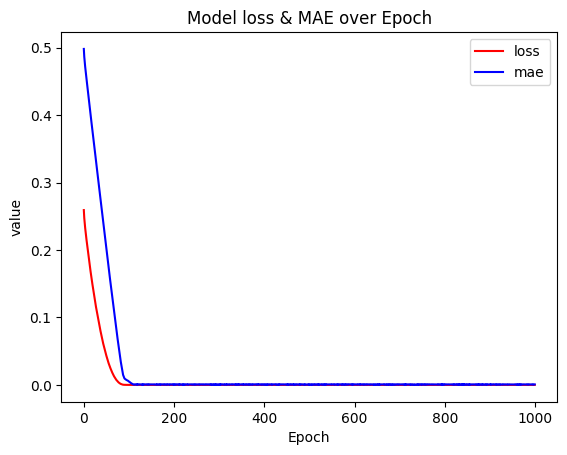

In [13]:
plt.plot(hist.history.get('loss'), color='r', label='loss')
plt.plot(hist.history.get('mae'), color='b', label='mae')
plt.legend() # 범례 추가
plt.xlabel('Epoch')
plt.ylabel('value')
plt.title('Model loss & MAE over Epoch')
plt.show()

In [14]:
# 7. 모델 사용 및 저장
# 학습 후 예측
print(model.predict(np.array([[0],
                              [0.01]])))

1/1 [==============================] - 0s 32ms/step
[[0.3204353 ]
 [0.33843875]]


In [39]:
model.save('model/after_learning.h5')

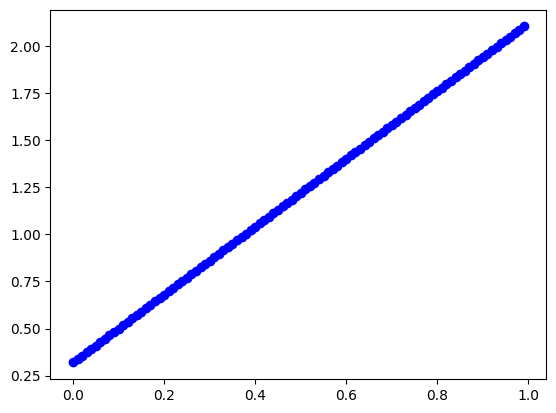

In [15]:
plt.scatter(x=scaled_data_C, y= scaled_data_F, c='b')
plt.show()

In [16]:
# 예측값
h_hat = model.predict([scaled_data_C])
for h, y in zip(h_hat, scaled_data_F) :
    print(f'예측값:{h}, 실제값 :{y}, 오차 : {y-h[0]}')

4/4 [==============================] - 0s 2ms/step
예측값:[0.3204353], 실제값 :0.32, 오차 : -0.000435285568237298
예측값:[0.33843875], 실제값 :0.33799999999999997, 오차 : -0.00043874931335452505
예측값:[0.35644218], 실제값 :0.35600000000000004, 오차 : -0.00044218325614925336
예측값:[0.37444565], 실제값 :0.374, 오차 : -0.0004456470012664804
예측값:[0.39244908], 실제값 :0.392, 오차 : -0.0004490809440612642
예측값:[0.41045254], 실제값 :0.41, 오차 : -0.0004525446891784912
예측값:[0.428456], 실제값 :0.428, 오차 : -0.00045600843429566273
예측값:[0.44645944], 실제값 :0.446, 오차 : -0.00045944237709044655
예측값:[0.46446288], 실제값 :0.46399999999999997, 오차 : -0.0004628763198852859
예측값:[0.48246634], 실제값 :0.48200000000000004, 오차 : -0.0004663400650024019
예측값:[0.5004698], 실제값 :0.5, 오차 : -0.0004698038101196289
예측값:[0.51847327], 실제값 :0.518, 오차 : -0.0004732675552368004
예측값:[0.53647673], 실제값 :0.536, 오차 : -0.00047673130035397193
예측값:[0.55448014], 실제값 :0.554, 오차 : -0.00048013544082636805
예측값:[0.5724836], 실제값 :0.5720000000000001, 오차 : -0.00048359918594353957
예측값:[0.590487

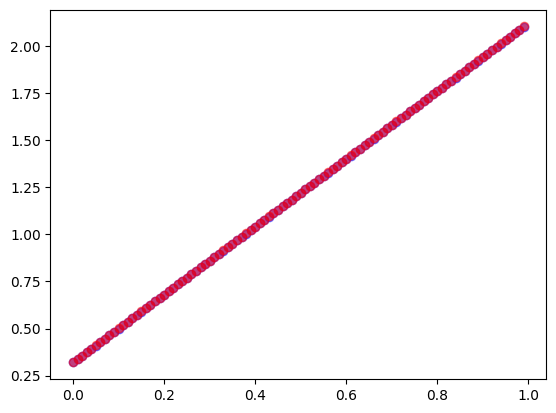

In [18]:
plt.scatter(x=scaled_data_C, y = scaled_data_F, c='b', alpha=0.5) # 반투명 그래프로 체크
plt.scatter(x=scaled_data_C, y = h_hat, c='r', alpha=0.5)
plt.show()

## 2.2 노이즈가 있는 데이터로 실습

In [23]:
np.random.seed(7)
noise = np.random.normal(0,scale=0.1,size=100) # 평균 0 표준 편차가 0.1인 100개 난수 데이터
noised_scaled_data_F = scaled_data_F + noise

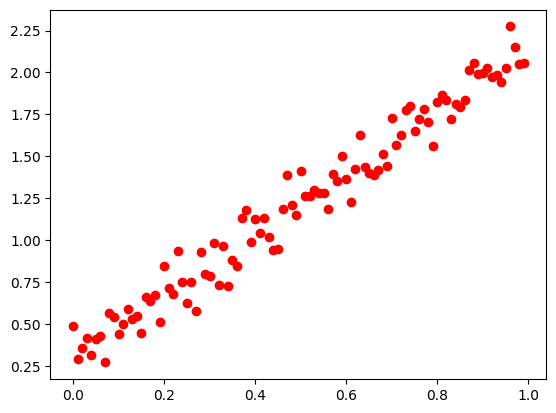

In [24]:
plt.scatter(x= scaled_data_C, y = noised_scaled_data_F, c = 'r')
plt.show()

In [25]:
# 3. 모델구성
model2 = Sequential()
model2.add(Dense(units=1, input_shape = (1,))) # 층 추가
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer = 'rmsprop', metrics = ['mae'])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [26]:
# 5. 모델 학습시키기
hist2 = model2.fit(scaled_data_C, noised_scaled_data_F, epochs=1000, verbose = 1)

Epoch 1/1000
4/4 [==============================] - 0s 7ms/step - loss: 4.4633 - mae: 1.8943
Epoch 2/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.4167 - mae: 1.8830
Epoch 3/1000
4/4 [==============================] - 0s 5ms/step - loss: 4.3824 - mae: 1.8746
Epoch 4/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.3546 - mae: 1.8679
Epoch 5/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.3281 - mae: 1.8613
Epoch 6/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.3003 - mae: 1.8545
Epoch 7/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.2764 - mae: 1.8487
Epoch 8/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.2519 - mae: 1.8427
Epoch 9/1000
4/4 [==============================] - 0s 2ms/step - loss: 4.2281 - mae: 1.8366
Epoch 10/1000
4/4 [==============================] - 0s 3ms/step - loss: 4.2056 - mae: 1.8310
Epoch 11/1000
4/4 [==============================] - 0s 3ms/step - lo

4/4 [==============================] - 0s 2ms/step - loss: 1.3309 - mae: 0.9419
Epoch 175/1000
4/4 [==============================] - 0s 0s/step - loss: 1.3193 - mae: 0.9376
Epoch 176/1000
4/4 [==============================] - 0s 875us/step - loss: 1.3072 - mae: 0.9332
Epoch 177/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2951 - mae: 0.9286
Epoch 178/1000
4/4 [==============================] - 0s 1ms/step - loss: 1.2835 - mae: 0.9242
Epoch 179/1000
4/4 [==============================] - 0s 1ms/step - loss: 1.2725 - mae: 0.9202
Epoch 180/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2614 - mae: 0.9159
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 1.2501 - mae: 0.9115
Epoch 182/1000
4/4 [==============================] - 0s 1ms/step - loss: 1.2378 - mae: 0.9069
Epoch 183/1000
4/4 [==============================] - 0s 1ms/step - loss: 1.2267 - mae: 0.9027
Epoch 184/1000
4/4 [==============================] - 0s 2ms/ste

4/4 [==============================] - 0s 5ms/step - loss: 0.3174 - mae: 0.4852
Epoch 347/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3162 - mae: 0.4842
Epoch 348/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.3148 - mae: 0.4831
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3135 - mae: 0.4822
Epoch 350/1000
4/4 [==============================] - 0s 4ms/step - loss: 0.3121 - mae: 0.4811
Epoch 351/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.3108 - mae: 0.4800
Epoch 352/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3096 - mae: 0.4790
Epoch 353/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.3089 - mae: 0.4785
Epoch 354/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.3078 - mae: 0.4776
Epoch 355/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.3065 - mae: 0.4766
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 666us/step - loss: 0.1627 - mae: 0.3439
Epoch 519/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1618 - mae: 0.3430
Epoch 520/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1610 - mae: 0.3422
Epoch 521/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.1603 - mae: 0.3413
Epoch 522/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.1594 - mae: 0.3405
Epoch 523/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.1585 - mae: 0.3395
Epoch 524/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1575 - mae: 0.3384
Epoch 525/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1568 - mae: 0.3376
Epoch 526/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1560 - mae: 0.3367
Epoch 527/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.1553 - mae: 0.3359
Epoch 528/1000
4/4 [==============================] - 0s 2ms/st

4/4 [==============================] - 0s 670us/step - loss: 0.0626 - mae: 0.2095
Epoch 691/1000
4/4 [==============================] - 0s 4ms/step - loss: 0.0623 - mae: 0.2091
Epoch 692/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0619 - mae: 0.2083
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0616 - mae: 0.2078
Epoch 694/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0612 - mae: 0.2071
Epoch 695/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0608 - mae: 0.2064
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0604 - mae: 0.2056
Epoch 697/1000
4/4 [==============================] - 0s 5ms/step - loss: 0.0600 - mae: 0.2050
Epoch 698/1000
4/4 [==============================] - 0s 752us/step - loss: 0.0596 - mae: 0.2042
Epoch 699/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0593 - mae: 0.2037
Epoch 700/1000
4/4 [==============================] - 0s 3ms/

4/4 [==============================] - 0s 3ms/step - loss: 0.0172 - mae: 0.1070
Epoch 863/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0171 - mae: 0.1064
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0170 - mae: 0.1063
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0169 - mae: 0.1058
Epoch 866/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0167 - mae: 0.1051
Epoch 867/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0167 - mae: 0.1049
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0166 - mae: 0.1043
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0165 - mae: 0.1041
Epoch 870/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0164 - mae: 0.1035
Epoch 871/1000
4/4 [==============================] - 0s 0s/step - loss: 0.0163 - mae: 0.1032
Epoch 872/1000
4/4 [==============================] - 0s 1ms/step 

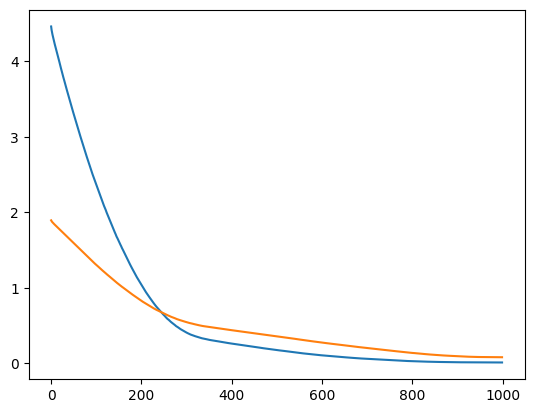

In [31]:
# 학습된 모델 과정 살펴보기
hist2.history.keys() # key : loss, mae
plt.plot(hist2.history['loss'])
plt.plot(hist2.history['mae'])

In [33]:
model2.save('model/noise_after_learning.h5')

In [34]:
# 예측값
y_hat = model2.predict([scaled_data_C])

4/4 [==============================] - 0s 2ms/step


In [37]:
for h, y in zip(y_hat, noised_scaled_data_F) :
    print(f'실제값 {y}, 예측값 {h}, 오차 {h[0]-y}')

실제값 0.48905257038003563, 예측값 [0.32269716], 오차 -0.1663554077518618
실제값 0.2914062629459167, 예측값 [0.3405329], 오차 0.04912663595697636
실제값 0.3592820163678585, 예측값 [0.35836866], 오차 -0.0009133513879238109
실제값 0.4147516282996508, 예측값 [0.3762044], 오차 -0.03854722704499686
실제값 0.31310769713742614, 예측값 [0.39404014], 오차 0.08093244039194702
실제값 0.4102065572905948, 예측값 [0.4118759], 오차 0.0016693463158199973
실제값 0.42791096141420687, 예측값 [0.42971164], 오차 0.0018006784669271636
실제값 0.2705275693654579, 예측값 [0.44754738], 오차 0.17701980679039536
실제값 0.5657658005663493, 예측값 [0.4653831], 오차 -0.10038268813577678
실제값 0.542049851591955, 예측값 [0.48321888], 오차 -0.05883097308434082
실제값 0.43745710260332404, 예측값 [0.50105464], 오차 0.06359754198133172
실제값 0.5008451738804279, 예측값 [0.5188904], 오차 0.01804520697894707
실제값 0.5865299374196752, 예측값 [0.5367261], 오차 -0.049803820285580946
실제값 0.5278643584808353, 예측값 [0.55456185], 오차 0.026697494927978127
실제값 0.5477250921327455, 예측값 [0.5723976], 오차 0.024672497550787265
실제값 0.444675858

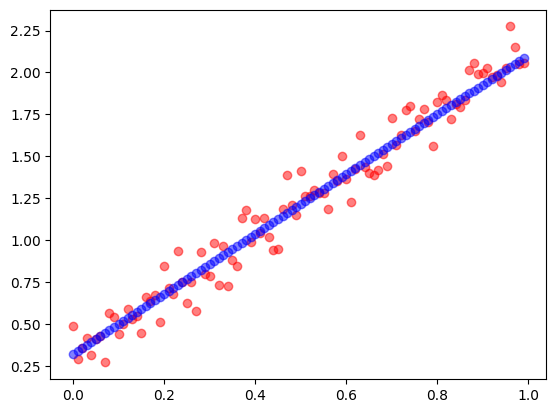

In [40]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F, c='r', alpha=0.5)
plt.scatter(x=scaled_data_C, y=y_hat, c='b', alpha=0.5)